<a href="https://colab.research.google.com/github/ingJuanArenas/SimulacionEA1/blob/main/Simulaci%C3%B3nEA1Principal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Configuración inicial y lógica de lanzamientos
En esta sección se importan las librerías necesarias para la generación de números aleatorios, el conteo de frecuencias y la visualización de datos. Asimismo, se definen las funciones fundamentales para simular el lanzamiento de dados y la estrategia básica de selección de valores basada en la frecuencia de aparición.

In [ ]:
import random
from collections import Counter
import matplotlib.pyplot as plt

def lanzar_dados(dados, bloqueados):
    return [dados[i] if bloqueados[i] else random.randint(1, 6) for i in range(5)]

def estrategia_basica(dados):
    """Estrategia: bloquear los dados del valor más común."""
    conteos = Counter(dados)
    if not conteos:
        return [False] * 5
    mas_comun = conteos.most_common(1)[0][0]
    return [d == mas_comun for d in dados]

### Definición de la lógica de puntuación
Esta función implementa el sistema de reglas para asignar puntajes. Evalúa la combinación de dados obtenida y clasifica la jugada en categorías como Yahtzee, Full House o Escaleras, retornando tanto el nombre de la jugada como el valor numérico de la puntuación.

In [ ]:
def calcular_puntuacion(dados):
    conteos = Counter(dados)
    frecuencias = sorted(conteos.values(), reverse=True)
    suma_total = sum(dados)
    set_dados = set(dados)

    if 5 in frecuencias: return ("YAHTZEE", 50)
    if 4 in frecuencias: return ("PÓKER", suma_total)
    if frecuencias == [3, 2]: return ("FULL HOUSE", 25)
    if {1,2,3,4,5}.issubset(set_dados) or {2,3,4,5,6}.issubset(set_dados): return ("ESCALERA LARGA", 40)
    if any(esc.issubset(set_dados) for esc in [{1,2,3,4}, {2,3,4,5}, {3,4,5,6}]): return ("ESCALERA CORTA", 30)
    if 3 in frecuencias: return ("TERCIA", suma_total)

    return ("PUNTUACIÓN BASE", suma_total)

### Implementación del turno
Se define la función principal de ejecución de turnos. Al integrar un parámetro de control para el modo silencioso, se permite reutilizar la misma lógica tanto para partidas visuales en consola como para ejecuciones masivas en simulaciones de alto rendimiento.

In [ ]:
def ejecutar_turno(jugador_id=None, silencioso=True, estrategia=estrategia_basica):
    """Unifica la lógica de turno aplicando DRY."""
    if not silencioso: print(f"\n--- TURNO JUGADOR {jugador_id} ---")

    intentos, dados, bloqueados = 3, [0]*5, [False]*5

    while intentos > 0:
        dados = lanzar_dados(dados, bloqueados)
        if not silencioso: print(f" Lanzamiento {4-intentos}: {dados} | Bloqueados: {bloqueados}")

        if intentos > 1:
            bloqueados = estrategia(dados)
            if all(bloqueados): break
        intentos -= 1

    jugada, puntos = calcular_puntuacion(dados)
    if not silencioso: print(f" Resultado final: {dados} -> {jugada} ({puntos} puntos)")
    return puntos


### Ejecución del modo interactivo
Esta sección contiene la estructura necesaria para llevar a cabo una partida completa de 13 rondas entre dos jugadores, mostrando paso a paso el desarrollo de los lanzamientos y el acumulado final de puntos.

In [ ]:
def iniciar_juego_interactivo():
    puntuaciones = {1: 0, 2: 0}
    for r in range(1, 14):
        print(f"\n=== RONDA {r} ===")
        for j in [1, 2]: puntuaciones[j] += ejecutar_turno(j, silencioso=False)
    print(f"\nRESULTADOS: J1: {puntuaciones[1]} | J2: {puntuaciones[2]}")


### Análisis estadístico mediante Simulación de Monte Carlo
Se implementa un análisis basado en 1000 iteraciones para determinar el comportamiento estadístico de la estrategia implementada. El código genera una distribución de frecuencias para evaluar el puntaje promedio y la probabilidad de éxito en un entorno competitivo.


--- SIMULACIÓN MONTE CARLO (10000 iteraciones) ---
Puntaje promedio J1: 261.23 | Prob. Victoria: 50.16%


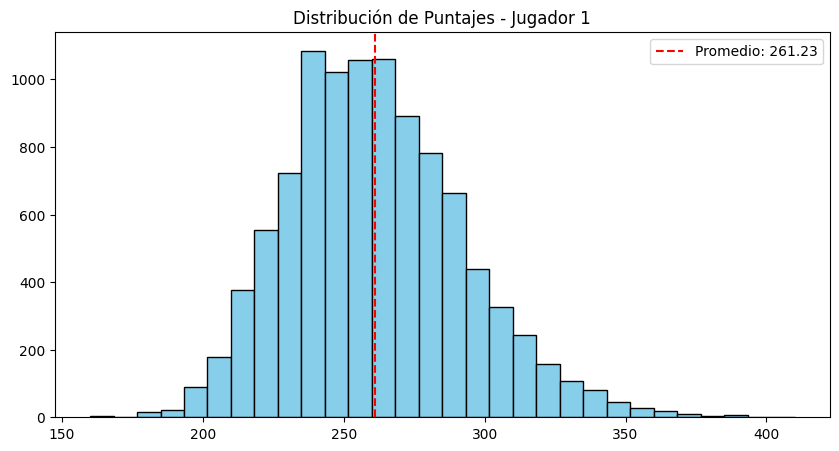

In [ ]:
def simular_montecarlo(iteraciones=1000):
    resultados_j1 = []
    victorias_j1 = 0
    print(f"\n--- SIMULACIÓN MONTE CARLO ({iteraciones} iteraciones) ---")

    for _ in range(iteraciones):
        puntos_j1 = sum(ejecutar_turno(silencioso=True) for _ in range(13))
        puntos_j2 = sum(ejecutar_turno(silencioso=True) for _ in range(13))
        resultados_j1.append(puntos_j1)
        if puntos_j1 > puntos_j2: victorias_j1 += 1

    promedio_j1 = sum(resultados_j1) / iteraciones
    print(f'Puntaje promedio J1: {promedio_j1:.2f} | Prob. Victoria: {(victorias_j1/iteraciones)*100:.2f}%')

    plt.figure(figsize=(10, 5))
    plt.hist(resultados_j1, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(promedio_j1, color='red', linestyle='--', label=f'Promedio: {promedio_j1:.2f}')
    plt.title('Distribución de Puntajes - Jugador 1')
    plt.legend()
    plt.show()

# Ejecución
simular_montecarlo(10000)